In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])

from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import ParameterSampler
from src.injection import SignalInjector
from src.waveform import WaveformGenerator

%cd ../

cwd: /home/victor/gw/cbc_pe/notebooks
sys.path: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '']
/home/victor/gw/cbc_pe


#### CONFIG / PARAMETERS / SAMPLING

In [ ]:
import numpy as np

from src.config import SimulationConfig
from src.sampling import PriorConfig, ParameterSampler

config = SimulationConfig()
rng = np.random.default_rng(1234)

prior = PriorConfig.bbh()
sampler = ParameterSampler(prior_config=prior, rng=rng)

samples = sampler.sample_many(1000)

assert all(p.mass_1 >= p.mass_2 for p in samples)
assert all(p.mass_1 >= 5.0 and p.mass_2 >= 5.0 for p in samples)
assert all(p.mass_1 <= 90.0 and p.mass_2 <= 90.0 for p in samples)
assert all(p.distance > 0 for p in samples)
assert all(0.0 <= p.inclination <= np.pi for p in samples)
assert all(0.0 <= p.ra <= 2 * np.pi for p in samples)
assert all(-np.pi / 2 <= p.dec <= np.pi / 2 for p in samples)
assert all(-1.0 <= p.spin_1z <= 1.0 for p in samples)
assert all(-1.0 <= p.spin_2z <= 1.0 for p in samples)

print("Bloque 1 OK")
print("Example:", samples[0])
print("chirp_mass:", samples[0].chirp_mass)
print("total_mass:", samples[0].total_mass)
print("chi_eff:", samples[0].chi_eff)

In [ ]:
# Checking swap
from src.parameters import CBCParameters

p = CBCParameters(
    mass_1=10.0,
    mass_2=30.0,
    distance=1000.0,
    inclination=1.0,
    ra=1.0,
    dec=0.2,
    spin_1z=0.1,
    spin_2z=0.8,
    polarization_angle=0.3,
)

assert p.mass_1 == 30.0
assert p.mass_2 == 10.0
assert p.spin_1z == 0.8
assert p.spin_2z == 0.1

#### DETECTORS / WINDOWING / WAVEFORM

In [ ]:
import numpy as np

from src.config import SimulationConfig
from src.sampling import PriorConfig, ParameterSampler
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector
from src.windowing import ProjectedNetworkWindowSelector

config = SimulationConfig()
rng = np.random.default_rng(1234)

sampler = ParameterSampler(PriorConfig.bbh(), rng=rng)
params = sampler.sample_one()

wavegen = WaveformGenerator(config)
waveform = wavegen.generate(params)

geocentric_time = 1126259462.0

projector = DetectorProjector(["H1", "L1", "V1"])
projected = projector.project(
    waveform.h_plus,
    waveform.h_cross,
    params,
    geocentric_coalescence_time=geocentric_time,
)

print("Waveform duration:", waveform.metadata.duration)
print("Waveform relative start:", waveform.metadata.start_time)
print("Waveform relative end:", waveform.metadata.end_time)

for det, strain in projected.strains.items():
    delay = projected.metadata.expected_detector_time_delays[det]
    expected_arrival = geocentric_time + delay
    expected_start = geocentric_time + waveform.metadata.start_time + delay
    actual_start = float(strain.start_time)

    print(det)
    print("  delay:", delay)
    print("  expected arrival:", expected_arrival)
    print("  expected start:", expected_start)
    print("  actual start:", actual_start)
    print("  start error:", actual_start - expected_start)
    print("  end:", float(strain.start_time) + len(strain) * float(strain.delta_t))

In [ ]:
selector = ProjectedNetworkWindowSelector(config)
windowed = selector.select(projected.strains)

print(windowed.metadata)

for det, strain in windowed.strains.items():
    used_start = float(strain.start_time)
    used_end = used_start + len(strain) * float(strain.delta_t)
    arrival = projected.metadata.detector_arrival_times[det]

    print(det)
    print("  used_start:", used_start)
    print("  used_end:", used_end)
    print("  arrival:", arrival)
    print("  arrival inside:", used_start <= arrival <= used_end)
    print("  seconds before arrival:", arrival - used_start)
    print("  seconds after arrival:", used_end - arrival)

#### NOISE / INJECTION / SNR

In [ ]:
injector = SignalInjector(config=config)

placement = injector.choose_segment_placement_containing_network(
    windowed.strains,
    placement_policy="random_contained",
)

for det, signal in windowed.strains.items():
    sig_start = float(signal.start_time)
    sig_end = sig_start + len(signal) * float(signal.delta_t)

    assert placement.segment_start_time <= sig_start
    assert sig_end <= placement.segment_end_time

print("Placement contains full network.")

In [ ]:
zero_noises = {
    det: injector.build_zero_strain(placement.segment_start_time)
    for det in windowed.strains
}

injected = injector.inject_network(
    noises=zero_noises,
    signals=windowed.strains,
)

for det, result in injected.items():
    print(det, result.n_injected_samples, result.n_signal_samples, result.is_partially_clipped)
    assert result.n_injected_samples == result.n_signal_samples
    assert not result.is_partially_clipped

print("Signal-only injection OK.")

In [ ]:
from src.noise import NoiseModel
from src.snr import compute_detector_optimal_snr, compute_network_optimal_snr, decide_distance_rescaling, validate_snr_rescaling, rescale_distance_for_target_network_snr

signal_segments = {
    det: result.strain
    for det, result in injected.items()
}
noise_model = NoiseModel(config)

detector_snrs, network_snr = compute_network_optimal_snr(
    signal_segments=signal_segments,
    psds={det: noise_model.get_psd(det) for det in signal_segments},
    config=config,
)

print("Detector SNRs:", detector_snrs)
print("Network SNR:", network_snr)

assert np.isfinite(network_snr)
assert network_snr > 0

In [ ]:
from src.snr import (
    decide_distance_rescaling,
    rescale_distance_for_target_network_snr,
    compute_network_optimal_snr,
    validate_snr_rescaling,
)

# 1. Decide si hay que reescalar
decision = decide_distance_rescaling(
    current_distance=params.distance,
    current_network_snr=network_snr,
    target_network_snr_range=config.target_network_snr_range,
    rng=rng,
)

print("decision:", decision)
print("old distance:", params.distance)
print("current network snr:", network_snr)
print("target network snr:", decision.target_network_snr)
print("new distance:", decision.new_distance)

# 2. Si ya está en rango, no hay reescalado que validar
if not decision.should_rescale:
    print("No rescaling needed. Current SNR already inside target range.")
    final_network_snr = network_snr

else:
    # 3. Crear nuevos parámetros con distancia reescalada
    params_rescaled = params.with_distance(decision.new_distance)

    # 4. Regenerar waveform con la nueva distancia
    waveform_rescaled = wavegen.generate(params_rescaled)

    # 5. Proyectar otra vez
    projected_rescaled = projector.project(
        waveform_rescaled.h_plus,
        waveform_rescaled.h_cross,
        params_rescaled,
        geocentric_coalescence_time=geocentric_time,
    )

    # 6. Windowing otra vez
    windowed_rescaled = selector.select(projected_rescaled.strains)

    # 7. Para este test, puedes reutilizar el MISMO placement_start_time
    #    que usaste antes. Así aíslas el efecto de la distancia.
    zero_noises_rescaled = {
        det: injector.build_zero_strain(placement.segment_start_time)
        for det in windowed_rescaled.strains
    }

    signal_only_rescaled = injector.inject_network(
        noises=zero_noises_rescaled,
        signals=windowed_rescaled.strains,
    )

    # 8. Comprobar que no hay clipping
    for det, result in signal_only_rescaled.items():
        print(
            det,
            "n_signal_samples:", result.n_signal_samples,
            "n_injected_samples:", result.n_injected_samples,
            "clipped:", result.is_partially_clipped,
        )

        assert not result.is_partially_clipped
        assert result.n_injected_samples == result.n_signal_samples

    # 9. Preparar segmentos signal-only de 4 s
    signal_segments_rescaled = {
        det: result.strain
        for det, result in signal_only_rescaled.items()
    }

    psds = {
        det: noise_model.get_psd(det)
        for det in signal_segments_rescaled
    }

    # 10. Recalcular SNR final
    detector_snrs_rescaled, final_network_snr = compute_network_optimal_snr(
        signal_segments=signal_segments_rescaled,
        psds=psds,
        config=config,
    )

    print("detector_snrs_rescaled:", detector_snrs_rescaled)
    print("final_network_snr:", final_network_snr)
    print("target_network_snr:", decision.target_network_snr)

    # 11. Validar
    validate_snr_rescaling(
        final_network_snr=final_network_snr,
        target_network_snr=decision.target_network_snr,
        relative_tolerance=config.snr_relative_tolerance,
    )

    print("SNR rescaling validation OK.")

In [ ]:
expected_ratio = params.distance / decision.new_distance
actual_ratio = final_network_snr / network_snr

print("expected amplitude/SNR ratio:", expected_ratio)
print("actual SNR ratio:", actual_ratio)
print("ratio error:", abs(actual_ratio - expected_ratio))

#### LABELS / PROCESSING

In [ ]:
from src.labels import LabelTransformer

labeler = LabelTransformer()

y = labeler.transform(params, standardize=False)

assert y.shape == (3,)
assert np.all(np.isfinite(y))
assert y[0] > 0          # chirp mass
assert y[1] > 0          # total mass
assert -1.0 <= y[2] <= 1.0  # chi_eff

print("Labels:", dict(zip(labeler.label_names, y)))
print("Labels metadata:", labeler.metadata())

In [ ]:
from src.processing import SignalProcessor

processor = SignalProcessor(
    config=config,
    apply_whitening=False,
    apply_lowpass=False,
    apply_highpass=False,
    apply_standardization=False,
    preserve_length=True,
)





placement = injector.choose_segment_placement_containing_network(
    windowed_rescaled.strains,
    placement_policy="random_contained",
)

zero_segments = {
    det: injector.build_zero_strain(placement.segment_start_time)
    for det in windowed_rescaled.strains
}

signal_only_results = injector.inject_network(
    noises=zero_segments,
    signals=windowed_rescaled.strains,
)

signal_only_segments = {
    det: result.strain
    for det, result in signal_only_results.items()
}


noises = noise_model.sample_network(
    detector_names=list(windowed_rescaled.strains.keys()),
    seed=1234,
)

noises = {
    det: injector.set_strain_start_time(noise, placement.segment_start_time)
    for det, noise in noises.items()
}

injected_results = injector.inject_network(
    noises=noises,
    signals=windowed_rescaled.strains,
)

noisy_segments = {
    det: result.strain
    for det, result in injected_results.items()
}

processed_network = processor.process_network(noisy_segments)


for det in processed_network:
    assert len(processed_network[det]) == config.length
    assert processed_network[det].delta_t == config.delta_t
    assert np.all(np.isfinite(processed_network[det].numpy()))


for det in processed_network:
    assert np.allclose(
        processed_network[det].numpy(),
        noisy_segments[det].numpy(),
    )

#### DATASET

In [ ]:
from src.dataset import DatasetBuilder

config = SimulationConfig()

builder = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs={
        "apply_whitening": False,
        "apply_lowpass": False,
        "apply_highpass": False,
        "apply_standardization": False,
        "preserve_length": True,
    },
    rng=np.random.default_rng(1234),
)

sample = builder.build_sample()

In [ ]:
assert sample.X.shape == (3, config.length)
assert sample.y.shape == (3,)
assert np.all(np.isfinite(sample.X))
assert np.all(np.isfinite(sample.y))

print("X shape:", sample.X.shape)
print("y:", sample.y)
print("final network SNR:", sample.metadata["snr"]["final_network_snr"])
print("SNR rescaled:", sample.metadata["snr"]["snr_rescaled"])
print("final params:", sample.metadata["final_parameters"])
print("placement:", sample.metadata["placement"])

In [ ]:
low, high = config.target_network_snr_range
snr = sample.metadata["snr"]["final_network_snr"]

assert low * (1 - config.snr_relative_tolerance) <= snr <= high * (1 + config.snr_relative_tolerance)

In [ ]:
for det in sample.metadata["detectors"]:
    inj = sample.metadata["injection"][det]
    assert not inj["is_partially_clipped"]
    assert inj["n_signal_samples"] == inj["n_injected_samples"]

In [ ]:
assert sample.X.dtype.kind in {"f", "c"}
assert sample.X.shape[0] == len(sample.metadata["detectors"])
assert sample.X.shape[1] == config.length

For n_samples=10

In [ ]:
batch = builder.build_dataset(num_samples=10)

assert batch.X.shape == (10, 3, config.length)
assert batch.y.shape == (10, 3)
assert len(batch.parameters) == 10
assert len(batch.metadata) == 10

snrs = np.array([
    m["snr"]["final_network_snr"]
    for m in batch.metadata
])

print("SNRs:", snrs)
print("min/max SNR:", snrs.min(), snrs.max())

low, high = config.target_network_snr_range
assert np.all(snrs >= low * (1 - config.snr_relative_tolerance))
assert np.all(snrs <= high * (1 + config.snr_relative_tolerance))

In [ ]:
m1 = np.array([p.mass_1 for p in batch.parameters])
m2 = np.array([p.mass_2 for p in batch.parameters])
dist = np.array([p.distance for p in batch.parameters])

print("m1 range:", m1.min(), m1.max())
print("m2 range:", m2.min(), m2.max())
print("distance range:", dist.min(), dist.max())

assert np.all(m1 >= m2)
assert np.all(m2 >= 5.0)

##### Window SC

##### Detectors SC

In [ ]:
from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.waveform import WaveformGenerator
from src.windowing import WaveformWindowSelector
from src.detectors import DetectorProjector

config = SimulationConfig(
    sampling_frequency=4096.0,
    duration=4.0,
    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",
    truncation_policy="keep_last_segment",
    required_final_duration=1.0,
)

params = CBCParameters(
    mass_1=10.0,
    mass_2=10.0,
    distance=1000.0,
    inclination=0.0,
    ra=1.0,
    dec=0.5,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.0,
)

generator = WaveformGenerator(config)
selector = WaveformWindowSelector(config)
projector = DetectorProjector()

waveform = generator.generate(params)
windowed = selector.select(waveform.h_plus, waveform.h_cross)

projection = projector.project(
    h_plus=windowed.h_plus,
    h_cross=windowed.h_cross,
    parameters=params,
    geocentric_coalescence_time=1126259462.0,
)

print("Delays:")
for ifo, delay in projection.metadata.expected_detector_time_delays.items():
    print(ifo, delay)

print("Arrival times:")
for ifo, arrival in projection.metadata.detector_arrival_times.items():
    print(ifo, arrival)

print("Projected strain start/end:")
for ifo, strain in projection.strains.items():
    end = float(strain.start_time) + len(strain) * float(strain.delta_t)
    print(ifo, float(strain.start_time), end, len(strain))

##### Noise SC

In [ ]:
from src.config import SimulationConfig
from src.noise import NoiseModel

config = SimulationConfig()
noise_model = NoiseModel(config)

for ifo in ["H1", "L1", "V1"]:
    psd = noise_model.get_psd(ifo)
    noise = noise_model.sample(ifo, seed=1234)

    print()
    print(ifo)
    print("psd length:", len(psd))
    print("psd delta_f:", psd.delta_f)
    print("noise length:", len(noise))
    print("noise delta_t:", noise.delta_t)
    print("noise duration:", len(noise) * noise.delta_t)

In [ ]:
noises_a = noise_model.sample_network(["H1", "L1", "V1"], seed=42)
noises_b = noise_model.sample_network(["H1", "L1", "V1"], seed=42)

for ifo in ["H1", "L1", "V1"]:
    print(ifo, (noises_a[ifo].numpy() == noises_b[ifo].numpy()).all())

print((noises_a["H1"].numpy() == noises_a["L1"].numpy()).all())

##### Injection SC

In [ ]:
from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.waveform import WaveformGenerator
from src.windowing import WaveformWindowSelector
from src.detectors import DetectorProjector
from src.noise import NoiseModel
from src.injection import SignalInjector


config = SimulationConfig(
    sampling_frequency=4096.0,
    duration=4.0,
    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",
    truncation_policy="keep_last_segment",
    required_final_duration=1.0,
)
for m in [30.0, 20.0, 10.0, 5.0]:


    params = CBCParameters(
        mass_1=m,
        mass_2=m,
        distance=1000.0,
        inclination=0.0,
        ra=1.0,
        dec=0.5,
        spin_1z=0.0,
        spin_2z=0.0,
        polarization_angle=0.0,
    )

    generator = WaveformGenerator(config)
    selector = WaveformWindowSelector(config)
    projector = DetectorProjector()
    noise_model = NoiseModel(config)
    injector = SignalInjector(config)

    geocentric_coalescence_time = 1126259462.0

    # 1. Generate waveform
    waveform = generator.generate(params)

    # 2. Select final window
    windowed = selector.select(
        waveform.h_plus,
        waveform.h_cross,
    )
    print("MASS = ", m)
    print("=== WINDOWING ===")
    print("full_duration:", windowed.metadata.full_duration)
    print("used_duration:", windowed.metadata.used_duration)
    print("is_truncated:", windowed.metadata.is_truncated)
    print("used_n_samples:", windowed.metadata.used_n_samples)
    print("used_start_time:", windowed.metadata.used_start_time)
    print("used_end_time:", windowed.metadata.used_end_time)

    # 3. Project to detectors
    projection = projector.project(
        h_plus=windowed.h_plus,
        h_cross=windowed.h_cross,
        parameters=params,
        geocentric_coalescence_time=geocentric_coalescence_time,
    )

    print("\n=== PROJECTION ===")
    for ifo, signal in projection.strains.items():
        signal_start = float(signal.start_time)
        signal_end = signal_start + len(signal) * float(signal.delta_t)
        print()
        print(ifo)
        print("delay:", projection.metadata.expected_detector_time_delays[ifo])
        print("arrival:", projection.metadata.detector_arrival_times[ifo])
        print("signal_start:", signal_start)
        print("signal_end:", signal_end)
        print("signal_length:", len(signal))
        print("signal_duration:", len(signal) * signal.delta_t)

    # 4. Build a common 4 s detector segment.
    #    We align the segment to end at the latest projected signal end time.
    latest_signal_end_time = max(
        float(signal.start_time) + len(signal) * float(signal.delta_t)
        for signal in projection.strains.values()
    )

    segment_start_time = latest_signal_end_time - config.duration
    segment_end_time = latest_signal_end_time

    print("\n=== COMMON SEGMENT ===")
    print("segment_start_time:", segment_start_time)
    print("segment_end_time:", segment_end_time)
    print("segment_duration:", segment_end_time - segment_start_time)

    # 5. Sample noise and assign the same absolute segment start to all detectors.
    noises = noise_model.sample_network(["H1", "L1", "V1"], seed=123)

    noises = {
        ifo: injector.set_strain_start_time(noise, segment_start_time)
        for ifo, noise in noises.items()
    }

    # 6. Inject network
    results = injector.inject_network(
        noises=noises,
        signals=projection.strains,
    )

    print("\n=== INJECTION ===")
    for ifo, result in results.items():
        print()
        print(ifo)
        print("final_strain_length:", len(result.strain))
        print("final_strain_duration:", len(result.strain) * result.strain.delta_t)
        print("segment_start:", result.segment_start_time)
        print("segment_end:", result.segment_end_time)
        print("signal_start:", result.signal_start_time)
        print("signal_end:", result.signal_end_time)
        print("raw_signal_indices:", result.signal_start_index, result.signal_end_index)
        print(
            "overlap_strain_indices:",
            result.overlap_start_index_strain,
            result.overlap_end_index_strain,
        )
        print(
            "overlap_signal_indices:",
            result.overlap_start_index_signal,
            result.overlap_end_index_signal,
        )
        print("n_signal_samples:", result.n_signal_samples)
        print("n_injected_samples:", result.n_injected_samples)
        print("n_clipped_before:", result.n_clipped_before)
        print("n_clipped_after:", result.n_clipped_after)
        print("is_partially_clipped:", result.is_partially_clipped)

        assert len(result.strain) == config.length
        assert result.strain.delta_t == config.delta_t
        assert 0 <= result.overlap_start_index_strain < config.length
        assert 0 < result.overlap_end_index_strain <= config.length
        assert result.n_injected_samples > 0


        max_allowed_clipped_before_seconds = 0.05
        max_allowed_clipped_after_seconds = 0.0

        for ifo, result in results.items():
            clipped_before_seconds = result.n_clipped_before * config.delta_t
            clipped_after_seconds = result.n_clipped_after * config.delta_t

            assert clipped_before_seconds <= max_allowed_clipped_before_seconds, (
                ifo,
                clipped_before_seconds,
            )

            assert clipped_after_seconds <= max_allowed_clipped_after_seconds, (
                ifo,
                clipped_after_seconds,
            )

##### SNR SC

In [ ]:
from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.waveform import WaveformGenerator
from src.windowing import WaveformWindowSelector
from src.detectors import DetectorProjector
from src.noise import NoiseModel
from src.injection import SignalInjector
from src.snr import (
    compute_network_optimal_snr,
    rescale_distance_for_target_network_snr,
)

config = SimulationConfig(
    sampling_frequency=4096.0,
    duration=4.0,
    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",
    truncation_policy="keep_last_segment",
    required_final_duration=1.0,
)

params = CBCParameters(
    mass_1=10.0,
    mass_2=10.0,
    distance=1000.0,
    inclination=0.0,
    ra=1.0,
    dec=0.5,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.0,
)

generator = WaveformGenerator(config)
selector = WaveformWindowSelector(config)
projector = DetectorProjector()
noise_model = NoiseModel(config)
injector = SignalInjector(config)

# 1. Generate waveform
waveform = generator.generate(params)

# 2. Select final window if needed
windowed = selector.select(
    waveform.h_plus,
    waveform.h_cross,
)

# 3. Project to detectors using geocentric reference time
projection = projector.project(
    h_plus=windowed.h_plus,
    h_cross=windowed.h_cross,
    parameters=params,
    geocentric_coalescence_time=1126259462.0,
)

# 4. Choose one common 4 s segment that contains the projected network signal
placement = injector.choose_segment_placement_containing_network(
    signals=projection.strains,
    placement_policy="random_contained",
)

# 5. Build zero-valued 4 s signal segments with the chosen common start time
zero_segments = {
    ifo: injector.build_zero_strain(
        start_time=placement.segment_start_time,
    )
    for ifo in projection.strains
}

# 6. Insert projected signals into the zero segments
signal_segment_results = injector.inject_network(
    noises=zero_segments,
    signals=projection.strains,
)

signal_segments = {
    ifo: result.strain
    for ifo, result in signal_segment_results.items()
}

# 7. Get matching PSDs
psds = {
    ifo: noise_model.get_psd(ifo)
    for ifo in signal_segments
}

# 8. Compute detector and network SNR
detector_snrs, network_snr = compute_network_optimal_snr(
    signal_segments=signal_segments,
    psds=psds,
    config=config,
)

print("Placement:")
print("segment_start_time:", placement.segment_start_time)
print("segment_end_time:", placement.segment_end_time)
print("network_signal_duration:", placement.signal_network_duration)

print("\nInjection indices:")
for ifo, result in signal_segment_results.items():
    print(
        ifo,
        result.signal_start_index,
        result.signal_end_index,
        "len:",
        len(result.strain),
    )

print("\nDetector SNRs:")
print(detector_snrs)

print("\nNetwork SNR:")
print(network_snr)

# 9. Test distance rescaling
target = 15.0

new_distance = rescale_distance_for_target_network_snr(
    current_distance=params.distance,
    current_network_snr=network_snr,
    target_network_snr=target,
)

print("\nDistance rescaling:")
print("old distance:", params.distance)
print("new distance:", new_distance)

# 10. Quick amplitude scaling check
scale = target / network_snr

scaled_signal_segments = {
    ifo: segment * scale
    for ifo, segment in signal_segments.items()
}

scaled_detector_snrs, scaled_network_snr = compute_network_optimal_snr(
    signal_segments=scaled_signal_segments,
    psds=psds,
    config=config,
)

print("\nScaled SNR check:")
print(scaled_detector_snrs)
print("scaled_network_snr:", scaled_network_snr)

##### DATASET SC

In [ ]:
from src.config import SimulationConfig
from src.dataset import DatasetBuilder
from src.parameters import CBCParameters

config = SimulationConfig(
    sampling_frequency=4096.0,
    duration=4.0,
    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",
    truncation_policy="keep_last_segment",
    required_final_duration=1.0,
    target_network_snr_range=(10.0, 25.0),
    simulation_regime="BBH",
    waveform_family="IMR",
)

builder = DatasetBuilder.from_config(config)

test_params = [
    CBCParameters(
        mass_1=30.0,
        mass_2=30.0,
        distance=1000.0,
        inclination=0.0,
        ra=1.0,
        dec=0.5,
        spin_1z=0.0,
        spin_2z=0.0,
        polarization_angle=0.0,
    ),
    CBCParameters(
        mass_1=10.0,
        mass_2=10.0,
        distance=1000.0,
        inclination=0.0,
        ra=1.0,
        dec=0.5,
        spin_1z=0.0,
        spin_2z=0.0,
        polarization_angle=0.0,
    ),
    CBCParameters(
        mass_1=5.0,
        mass_2=5.0,
        distance=1000.0,
        inclination=0.0,
        ra=1.0,
        dec=0.5,
        spin_1z=0.0,
        spin_2z=0.0,
        polarization_angle=0.0,
    ),
]

for params in test_params:
    sample = builder.build_sample(
        params=params,
        standardize_labels=False,
        placement_policy="random_contained",
    )

    print()
    print(f"{params.mass_1}+{params.mass_2}")
    print("X shape:", sample.X.shape)
    print("final SNR:", sample.metadata["snr"]["final_network_snr"])
    print("rescaled:", sample.metadata["snr"]["snr_rescaled"])
    print("truncated:", sample.metadata["windowing"]["is_truncated"])
    print("full network duration:", sample.metadata["windowing"]["full_network_duration"])
    print("used window duration:", sample.metadata["windowing"]["used_window_duration"])
    print("placement network duration:", sample.metadata["placement"]["signal_network_duration"])

##### PROCESSING SC 

In [ ]:
builder = DatasetBuilder.from_config(
    config,
    signal_processor_kwargs={
        "apply_whitening": False,
        "apply_lowpass": False,
        "apply_highpass": False,
        "apply_standardization": False,
    },
)

sample = builder.build_sample()
print(sample.X.shape)
print(np.mean(sample.X, axis=1), np.std(sample.X, axis=1))
print(sample.metadata["processing"])

In [ ]:
builder = DatasetBuilder.from_config(
    config,
    signal_processor_kwargs={
        "apply_standardization": True,
    },
)

sample = builder.build_sample()
print(sample.X.shape)
print(sample.X.mean(axis=1))
print(sample.X.std(axis=1))

In [ ]:
builder = DatasetBuilder.from_config(
    config,
    signal_processor_kwargs={
        "apply_whitening": True,
        "apply_highpass": True,
        "apply_lowpass": True,
        "apply_standardization": True,
    },
)
sample = builder.build_sample()
print(sample.X.shape)

##### IO SC

In [ ]:
from pathlib import Path
from src.io import save_dataset_npz, load_dataset_npz

batch = builder.build_dataset(
    num_samples=5,
    standardize_labels=False,
    placement_policy="random_contained",
)

path = save_dataset_npz(
    batch=batch,
    output_dir=Path("data/test"),
    file_name="bbh_debug_dataset.npz",
    detector_names=["H1", "L1", "V1"],
    overwrite=True,
)

loaded = load_dataset_npz(path)

print(loaded.X.shape)
print(loaded.y.shape)
print(len(loaded.parameters))
print(len(loaded.metadata))
print(loaded.metadata[0]["snr"])
print(loaded.metadata[0]["windowing"])

## SimulationConfig

In [ ]:
config = SimulationConfig()

print("sampling_frequency (Hz):", config.sampling_frequency)
print("duration (s):", config.duration)
print("delta_t (s):", config.delta_t)
print("length:", config.length)
print("delta_f (Hz):", config.delta_f)
print("flength:", config.flength)
print("approximant", config.waveform_approximant)

In [ ]:

params = CBCParameters(
    mass_1=30,
    mass_2=30,
    distance=1000.0,
    inclination=0.0,
    ra=0.0,
    dec=0.0,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.0,
)

waveform = WaveformGenerator(config).generate(params)

print(waveform.metadata.duration)
print(waveform.metadata.start_time)
print(waveform.metadata.end_time)
print(waveform.h_plus.sample_times[0])
print(waveform.h_plus.sample_times[-1])

## CBCParameters

In [ ]:
for m in [30, 20, 10, 5, 3, 2, 1.4, 1.0]:
    params = CBCParameters(
        mass_1=m,
        mass_2=m,
        distance=1000.0,
        inclination=0.0,
        ra=0.0,
        dec=0.0,
        spin_1z=0.0,
        spin_2z=0.0,
        polarization_angle=0.0,
    )

    try:
        waveform = WaveformGenerator(config).generate(params)
        print(
            m,
            "OK",
            waveform.metadata.duration,
            waveform.metadata.start_time,
            waveform.metadata.end_time,
        )
    except Exception as e:
        print(m, "FAILED", type(e).__name__, str(e).split("\n")[0])

In [ ]:
params = CBCParameters(
    mass_1=20.0,
    mass_2=40.0,
    distance=500.0,
    inclination=np.pi / 3,
    ra=1.2,
    dec=0.4,
    spin_1z=0.3,
    spin_2z=-0.2,
)

print(params)
print("mass_1 (Msun):", params.mass_1)
print("mass_2 (Msun):", params.mass_2)
print("total_mass (Msun):", params.total_mass)
print("chirp_mass (Msun):", params.chirp_mass)
print("chi_eff:", params.chi_eff)

## ParameterSampler

In [ ]:
sampler = ParameterSampler(rng=np.random.default_rng(42))
samples = sampler.sample_many(50000)

print(type(samples[0]))
print(samples[0])

mass_1 = np.array([s.mass_1 for s in samples])
mass_2 = np.array([s.mass_2 for s in samples])
inclinations = np.array([s.inclination for s in samples])
ras = np.array([s.ra for s in samples])
decs = np.array([s.dec for s in samples])

print(np.all(mass_1 >= mass_2))
print(ras.min(), ras.max())
print(decs.min(), decs.max())
print(inclinations.min(), inclinations.max())

### Isotropic checks for cos(i) and sin(dec)

In [ ]:
cos_i = np.cos(inclinations)
sin_dec = np.sin(decs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(cos_i, bins=25)
ax[0].set_title(f"cos($\iota$)")

ax[1].hist(sin_dec, bins=25)
ax[1].set_title(f"sin($\tDEC$)")

plt.tight_layout()
plt.show()

## SignalInjector

In [ ]:
from src.noise import NoiseModel
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector

import lal as _lal

noise_model = NoiseModel(config=config)
noise = noise_model.sample(detector_name="V1")

waveform_generator = WaveformGenerator(config=config)
hp, hc = waveform_generator.generate(parameters=params)

detector_projector = DetectorProjector()
projected_signal = detector_projector.project(h_plus=hp, h_cross=hc, parameters=params)

signal_injector = SignalInjector(config=config)
injected_signal = signal_injector.inject(strain=noise, signal=projected_signal["V1"])

############### PLOTTING ###############

print(injected_signal)
t = np.arange(config.length) * config.delta_t

# plot the noise, signal, and injected signal
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, noise)   
ax[0].set_title("Noise")


ax[1].plot(t, injected_signal.strain)
ax[1].set_title("Injected Signal")
# Band with the duration of the signal above the injected signal plot
ax[1].axvspan(
    injected_signal.injection_time,
    injected_signal.injection_time + len(projected_signal["V1"])*projected_signal["V1"].delta_t,
    color='red',
    alpha=0.3,
    zorder=2)
ax[1].axvline(injected_signal.injection_time, color='red', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Strain ($h(t)$)")
ax[1].legend()

# Vertical line at the injection time
plt.tight_layout()
plt.show()



## SignalProcessor

In [ ]:
from src.processing import SignalProcessor

processor = SignalProcessor(
    config=config,
    apply_whitening=True,
    apply_lowpass=True,
    apply_highpass=True,
    apply_standardization=True,
    preserve_length=True,
    lowpass_frequency=350.0,
    highpass_frequency=30.0,
)



processed_signal = processor.process(injected_signal.strain)
print(type(processed_signal))
print(len(injected_signal.strain), len(processed_signal))
print("injected_signal.delta_f:",injected_signal.strain.delta_f)
print("injected_signal.delta_t:",injected_signal.strain.delta_t)
print("processed_signal.delta_f:",processed_signal.delta_f)
print("processed_signal.duration:",processed_signal.duration)
print("injected_signal.strain.duration:",injected_signal.strain.duration)

print("original start_time:", injected_signal.strain.start_time)
print("processed start_time:", processed_signal.start_time)
print("crop left time:", processed_signal.start_time - injected_signal.strain.start_time)

left_crop_samples = int(((processed_signal.start_time - injected_signal.strain.start_time) / processed_signal.delta_t))
print("left_crop_samples:", left_crop_samples)

print("original start_time:", injected_signal.strain.start_time)
print("processed start_time:", processed_signal.start_time)
print("original length:", len(injected_signal.strain))
print("processed length:", len(processed_signal))



In [ ]:
############### PLOTTING ###############

t = np.arange(config.length) * config.delta_t
t_processed = np.arange(len(processed_signal)) * processed_signal.delta_t + processed_signal.start_time
t_projected = np.arange(len(projected_signal["V1"])) * projected_signal["V1"].delta_t + injected_signal.injection_time

# plot the noise, signal, and injected signal
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, injected_signal.strain, color='steelblue', label="Strain")  
ax[0].plot(t_projected, projected_signal["V1"], color='goldenrod', linestyle='-', alpha=0.7, label="Original Signal") 
ax[0].set_title("Pre-Processed Strain")
ax[0].axvline(injected_signal.injection_time, color='k', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Strain ($h(t)$)")
ax[0].legend()

ax[1].plot(t_processed, processed_signal, color='steelblue')
ax[1].set_title("Processed Strain")
ax[1].axvline(injected_signal.injection_time, color='k', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Strain ($h(t)$)")
ax[1].legend()

# Vertical line at the injection time
plt.tight_layout()
plt.show()
plt.close()

## Generating one-sample

In [ ]:
from src.config import SimulationConfig
from src.dataset import DatasetBuilder

config = SimulationConfig()
builder = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
        lowpass_frequency=350.0,
        highpass_frequency=30.0,
    ),
)

sample = builder.build_sample()

print(type(builder))
print(sample.X.shape)
print(sample.y.shape)
print(sample.parameters)
print(type(sample.parameters))


# Check if signal processor arguments are correctly applied
builder = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=False,
        preserve_length=True,
    ),
)

print(builder.signal_processor.apply_whitening)
print(builder.signal_processor.apply_lowpass)
print(builder.signal_processor.apply_highpass)
print(builder.signal_processor.preserve_length)


# Check if label transformer arguments are correctly applied
mean = np.array([10.0, 20.0, 0.0])
std = np.array([2.0, 5.0, 0.5])

builder = DatasetBuilder.from_config(
    config=config,
    label_transformer_kwargs=dict(mean=mean, std=std),
)

print(builder.label_transformer.mean)
print(builder.label_transformer.std)

# Check if preserve ordering of detectors name
builder = DatasetBuilder.from_config(
    config=config,
    detector_names=["V1", "H1"],
    signal_processor_kwargs=dict(preserve_length=True),
)

print(builder.detector_names)

sample = builder.build_sample()
print(sample.X.shape)

In [ ]:
# Check for reproducibility with rng
rng1 = np.random.default_rng(123)
rng2 = np.random.default_rng(123)

builder1 = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
    ),
    rng=rng1,
)

builder2 = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
    ),
    rng=rng2,
)

sample1 = builder1.build_sample()
sample2 = builder2.build_sample()

print(np.allclose(sample1.X, sample2.X))  #The noise introduced doesnt include a seed, all other physical parameters are reproducible
print(np.allclose(sample1.y, sample2.y))
print(sample1.parameters == sample2.parameters)

## ... and multiple samples

In [ ]:
batch = builder.build_dataset(num_samples=10)

print(batch.X.shape)
print(batch.y.shape)
print(batch.parameters[0])
print(len(batch.parameters))
print(type(batch.parameters[0]))

### TO DO LIST:
- Implementar una configuracion en la que se puede generar la dataset en un intervalo SNR reajustando consecuentemente la distancia (como el trabajo original)
- Decidir que tipo de input uso para la NN. 
    - Originalmente, CNN pero dando time-series. Si uso TS podría mirar otro tipo de arquitecturas mejor que CNN, quizá TCN (temporal), RNN o LSTMs. (MQRNN ?)
    - Quizá un spectrogtama con CNN podría ser más efectivo, o explorar otras arquitecturas. (NODE ? :  https://arxiv.org/abs/1806.07366)

# Mondrian (conformal binning) implementation example

In [ ]:
import numpy as np
import random

from src.conformal.binning import PredictionBinner, BinGrouper
from src.conformal.calibration import ConformalIntervalCalibrator
from src.conformal.apply import apply
from src.conformal.metrics import CoverageEvaluator

rng = np.random.default_rng(42)

# =========================
# 1) Synthetic calibration and test data
# =========================
n_cal = 400
n_test = 200
n_labels = 3

# True values for calibration
y_cal = np.column_stack([
    rng.normal(loc=25.0, scale=5.0, size=n_cal),    # chirp-like
    rng.normal(loc=60.0, scale=10.0, size=n_cal),   # total-mass-like
    rng.normal(loc=0.0, scale=0.3, size=n_cal),     # chi_eff-like
])

# Heteroscedastic noise: error depends a bit on the true value
cal_noise = np.column_stack([
    rng.normal(0.0, 0.8 + 0.03 * np.abs(y_cal[:, 0]), size=n_cal),
    rng.normal(0.0, 1.5 + 0.02 * np.abs(y_cal[:, 1]), size=n_cal),
    rng.normal(0.0, 0.05 + 0.10 * np.abs(y_cal[:, 2]), size=n_cal),
])

# Predictions are truth plus noise
pred_cal = y_cal + cal_noise

# Residuals in the convention y_true - y_pred
residuals_cal = y_cal - pred_cal

# Test data
y_test = np.column_stack([
    rng.normal(loc=25.0, scale=5.0, size=n_test),
    rng.normal(loc=60.0, scale=10.0, size=n_test),
    rng.normal(loc=0.0, scale=0.3, size=n_test),
])

test_noise = np.column_stack([
    rng.normal(0.0, 0.8 + 0.03 * np.abs(y_test[:, 0]), size=n_test),
    rng.normal(0.0, 1.5 + 0.02 * np.abs(y_test[:, 1]), size=n_test),
    rng.normal(0.0, 0.05 + 0.10 * np.abs(y_test[:, 2]), size=n_test),
])

pred_test = y_test + test_noise

print("pred_cal shape:", pred_cal.shape)
print("y_cal shape:", y_cal.shape)
print("residuals_cal shape:", residuals_cal.shape)
print("pred_test shape:", pred_test.shape)
print("y_test shape:", y_test.shape)





In [ ]:
# =========================
# 2) Mondrian pipeline
# =========================
n_bins = 24

binner = PredictionBinner(
    n_bins=n_bins,
    rng=np.random.default_rng(123),
    apply_jitter=True,
    jitter_variation=1e-10,
)

bin_indices_cal = binner.fit_transform(pred_cal)

grouper = BinGrouper(n_bins=n_bins)
grouped_residuals = grouper.group_by_bin(residuals_cal, bin_indices_cal)

calibrator = ConformalIntervalCalibrator(
    confidence_level=0.90,
    interval_mode="symmetric",
)
calibrator.fit(grouped_residuals)

bin_indices_test = binner.transform(pred_test)

lower, upper = apply(
    predictions=pred_test,
    bin_indices=bin_indices_test,
    intervals=calibrator.intervals_,
)

evaluator = CoverageEvaluator()
metrics = evaluator.evaluate(
    y=y_test,
    upper_bound=upper,
    lower_bound=lower,
    bin_indices=bin_indices_test,
)

print("bin_indices_cal shape:", bin_indices_cal.shape)
print("grouped_residuals shape:", grouped_residuals.shape)
print("intervals shape:", calibrator.intervals_.shape)
print("bin_indices_test shape:", bin_indices_test.shape)
print("lower shape:", lower.shape)
print("upper shape:", upper.shape)

In [ ]:
# =========================
# 3) Main metrics
# =========================
print("Global coverage:", metrics["global_coverage"])
print("Miscoverage:", metrics["miscoverage"])
print("Global mean width:", metrics["global_mean_width"])
print("Coverage per bin:", None if metrics["coverage_per_bin"] is None else metrics["coverage_per_bin"])
print("Mean width per bin:", None if metrics["mean_width_per_bin"] is None else metrics["mean_width_per_bin"])
print("Counts per bin:", None if metrics["counts_per_bin"] is None else metrics["counts_per_bin"])

In [ ]:
# Optional: readable per-bin display
label_names = [" -- CHIRP_MASS -- ", " -- TOTAL_MASS -- ", " -- CHI_EFF -- "]

for j, name in enumerate(label_names):
    print(f"\n{name}")
    print("global coverage:", metrics["global_coverage"][j])
    print("global mean width:", metrics["global_mean_width"][j])
    print("coverage per bin:", metrics["coverage_per_bin"][:, j])
    print("mean width per bin:", metrics["mean_width_per_bin"][:, j])
    print("counts per bin:", metrics["counts_per_bin"][:, j])

## Using the pipeline

In [ ]:
from src.conformal.pipeline import run_mondrian_regression
results = run_mondrian_regression(
    pred_cal=pred_cal,
    pred_test=pred_test,
    y_cal=y_cal,
    y_test=y_test,
    n_bins=12,
    confidence_level=0.90,
    apply_jitter=True,
)

print(results.intervals.shape)
print(results.lower.shape)
print(results.upper.shape)
print(results.metrics["global_coverage"])

## Plots (conformal)

## Checking time delays

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import CBCParameters
from src.sampling import ParameterSampler
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector
from src.noise import NoiseModel
from src.injection import SignalInjector
from src.processing import SignalProcessor
from src.labels import LabelTransformer
from src.dataset import DatasetBuilder

# Define the simulation configuration
config = SimulationConfig(
    sampling_frequency=4096.0,  # Hz
    duration=4.0,  # s
    low_frequency_cutoff=30.0,  # Hz
    waveform_approximant="SEOBNRv4",
)

# Define the parameter sampler
parameter_sampler = ParameterSampler()

# Define the waveform generator
waveform_generator = WaveformGenerator(config=config)

# Define the detector projector
detector_projector = DetectorProjector()

# Define the noise model
noise_model = NoiseModel(config=config)

# Define the signal injector
signal_injector = SignalInjector(config=config)

# Define the signal processor
signal_processor = SignalProcessor(config=config)

# Define the label transformer
label_transformer = LabelTransformer()

# Define the dataset builder
dataset_builder = DatasetBuilder(
    config=config,
    parameter_sampler=parameter_sampler,
    waveform_generator=waveform_generator,
    detector_projector=detector_projector,
    noise_model=noise_model,
    signal_injector=signal_injector,
    signal_processor=signal_processor,
    label_transformer=label_transformer,
)

# Sample a parameter
params = parameter_sampler.sample_one()

# Generate the waveform
hp, hc = waveform_generator.generate(params)

# Project the waveform onto the detector
projected_waveform = detector_projector.project(hp, hc, params)

max_signal_length = max((len(strain) for strain in projected_waveform.values()), default=0)
print(f"Max signal length: {max_signal_length}")

for name, strain in projected_waveform.items():
    print(f"{name}: {strain.start_time}, {strain.delta_t}, {strain.end_time}, {len(strain)}")

injection_time = dataset_builder.set_injection_time(max_signal_length)

#print("Noise start time: ", noise_model.sample("H1").start_time)

# Inject the waveform into the noise
injected_signal_H1 = signal_injector.inject(noise_model.sample("H1"), projected_waveform["H1"], injection_time=injection_time)
injected_signal_L1 = signal_injector.inject(noise_model.sample("L1"), projected_waveform["L1"], injection_time=injection_time)
injected_signal_V1 = signal_injector.inject(noise_model.sample("V1"), projected_waveform["V1"], injection_time=injection_time)

print("Signal time H1 (s):", injected_signal_H1.detector_start_time)
print("Signal time L1 (s):", injected_signal_L1.detector_start_time)
print("Signal time V1 (s):", injected_signal_V1.detector_start_time)
print(injected_signal_H1.detector_start_index)
print(injected_signal_L1.detector_start_index)
print(injected_signal_V1.detector_start_index)
print(injection_time)


The detector_start_time is the time of the injection in the event reference frame. That is, in the time frame of the strain. Where injection_time is the geocentric time of the injection.

## Checking the SNR module: waveform-PSD matching

In [ ]:
from src.snr import compute_detector_optimal_snr, compute_network_snr, rescale_distance_for_target_network_snr


noise_model = NoiseModel(config=config)


network_snr = []
for detector_name, waveform in projected_waveform.items():
    detector_noise = noise_model.psds[detector_name]

    optimal_snr = compute_detector_optimal_snr(waveform, detector_noise, config)
    network_snr.append(optimal_snr)
    print(f"Optimal SNR for {detector_name}: {optimal_snr}")

network_snr = np.array(network_snr)
print(f"Network SNR: {compute_network_snr(network_snr)}")


## Generation of a Dataset and Evaluation of distance rescaling

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from src.config import SimulationConfig
from src.sampling import ParameterSampler
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector
from src.noise import NoiseModel
from src.injection import SignalInjector
from src.processing import SignalProcessor
from src.labels import LabelTransformer
from src.dataset import DatasetBuilder
from src.snr import compute_detector_optimal_snr, compute_network_snr

In [ ]:
config = SimulationConfig(
    sampling_frequency = 4096.0,  # Hz
    duration = 4.0,  # s
    low_frequency_cutoff = 30.0,  # Hz
    waveform_approximant ="SEOBNRv4_opt",
    target_network_snr_range = (10.0, 25.0),
    snr_relative_tolerance = 0.05,
)


signal_processor_dict = {
    "apply_whitening": True, 
    "apply_lowpass": True, 
    "apply_highpass": True, 
    "apply_standardization": True, 
}
builder = DatasetBuilder.from_config(
    config,
    signal_processor_kwargs=signal_processor_dict)



In [ ]:
sample = builder.build_sample()

print("X shape:", np.array(sample.X).shape)
print("y shape:", np.array(sample.y).shape)
print("parameters:", sample.parameters)

print("NaN in X:", np.isnan(sample.X).any())
print("Inf in X:", np.isinf(sample.X).any())
print("NaN in y:", np.isnan(sample.y).any())
print("Inf in y:", np.isinf(sample.y).any())

In [ ]:
fig, axes = plt.subplots(sample.X.shape[0], 1, figsize=(12, 6), sharex=True)

detector_labels = ["H1", "L1", "V1"][:sample.X.shape[0]]
print(detector_labels)

for i in range(sample.X.shape[0]):
    times = config.delta_t * np.arange(len(sample.X[i]))
    axes[i].plot(times,sample.X[i])
    axes[i].set_ylabel(detector_labels[i])
    axes[i].axvline(sample.injection_time, color="k", alpha=0.4, linestyle="--", label=rf"$t_{{inj}}:$ %.2f s" % sample.injection_time)
    axes[i].set_xlim(sample.injection_time - 0.1, sample.injection_time + 0.1)

axes[-1].set_xlabel("Sample index")
plt.suptitle("Processed channels for one dataset sample")
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
from dataclasses import replace

params = builder.parameter_sampler.sample_one()

# Antes del rescaling
projected_waveform_before, network_snr_before = builder._generate_projected_waveforms_and_snr(params)

target_min, target_max = builder.config.target_network_snr_range
target_network_snr = builder.rng.uniform(target_min, target_max)

new_distance = (
    params.distance * network_snr_before / target_network_snr
)

params_rescaled = replace(params, distance=new_distance)

# Después del rescaling
projected_waveform_after, network_snr_after = builder._generate_projected_waveforms_and_snr(params_rescaled)

relative_error = abs(network_snr_after - target_network_snr) / target_network_snr

print(f"Original distance:      {params.distance:.3f}")
print(f"Original network SNR:   {network_snr_before:.3f}")
print(f"Target network SNR:     {target_network_snr:.3f}")
print(f"Rescaled distance:      {params_rescaled.distance:.3f}")
print(f"Final network SNR:      {network_snr_after:.3f}")
print(f"Relative SNR error:     {relative_error:.3f}")

In [ ]:
n_samples = 100

final_snrs = []
final_distances = []

for i in range(n_samples):
    sample = builder.build_sample()
    final_distances.append(sample.parameters.distance)

    _, final_network_snr = builder._generate_projected_waveforms_and_snr(sample.parameters)
    final_snrs.append(final_network_snr)

    if (i+1) % 10 == 0:
        print(f"Build samples {i+1} of {n_samples}. {(i+1)/n_samples:.2%} completed.".format(i=i, num_samples=n_samples))


final_snrs = np.array(final_snrs)
final_distances = np.array(final_distances)

print("Final SNR stats")
print("min:", final_snrs.min())
print("max:", final_snrs.max())
print("mean:", final_snrs.mean())
print("std:", final_snrs.std())

In [ ]:
plt.figure(figsize=(8, 5))
print(len(final_snrs))
plt.hist(final_snrs, color="steelblue",bins=15)
plt.axvline(builder.config.target_network_snr_range[0], linestyle="--", color="red", label="target min")
plt.axvline(builder.config.target_network_snr_range[1], linestyle="--", color="red", label="target max")
plt.xlabel("Final network SNR")
plt.ylabel("Count")
plt.title("Distribution of final network SNR")
plt.legend()
plt.show()

In [ ]:
batch = builder.build_dataset(num_samples=16)

print("Batch X shape:", batch.X.shape)
print("Batch y shape:", batch.y.shape)
print("Number of parameter sets:", len(batch.parameters))

print("NaN in batch X:", np.isnan(batch.X).any())
print("Inf in batch X:", np.isinf(batch.X).any())
print("NaN in batch y:", np.isnan(batch.y).any())
print("Inf in batch y:", np.isinf(batch.y).any())

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(final_distances, final_snrs)
plt.xlabel("Final distance")
plt.ylabel("Final network SNR")
plt.title("Final distance vs final network SNR")
plt.show()

In [ ]:
params = builder.parameter_sampler.sample_one()

# Antes del rescaling
projected_waveform_before, network_snr_before = builder._generate_projected_waveforms_and_snr(params)

target_min, target_max = builder.config.target_network_snr_range
target_network_snr = builder.rng.uniform(target_min, target_max)

new_distance = (
    params.distance * network_snr_before / target_network_snr
)

params_rescaled = replace(params, distance=new_distance)

# Después del rescaling
projected_waveform_after, network_snr_after = builder._generate_projected_waveforms_and_snr(params_rescaled)

relative_error = abs(network_snr_after - target_network_snr) / target_network_snr

print(f"Original distance:      {params.distance:.3f}")
print(f"Original network SNR:   {network_snr_before:.3f}")
print(f"Target network SNR:     {target_network_snr:.3f}")
print(f"Rescaled distance:      {params_rescaled.distance:.3f}")
print(f"Final network SNR:      {network_snr_after:.3f}")
print(f"Relative SNR error:     {relative_error:.3f}")

In [ ]:
params = builder.parameter_sampler.sample_one()

projected_waveform, network_snr = builder._generate_projected_waveforms_and_snr(params)

injection_time = builder.set_injection_time(
    projected_waveforms=projected_waveform,
    injection_time=None,
    rng=builder.rng,
)

print("Chosen geocentric injection_time:", injection_time)
print("Network SNR:", network_snr)

In [ ]:
params = builder.parameter_sampler.sample_one()
projected_waveform, current_network_snr = builder._generate_projected_waveforms_and_snr(params)

injection_time = builder.set_injection_time(
    projected_waveforms=projected_waveform,
    injection_time=None,
    rng=builder.rng,
)

strain_start = 0.0
strain_end = builder.config.duration

lower_bounds = []
upper_bounds = []

for det, waveform in projected_waveform.items():
    signal_start = float(waveform.start_time)
    signal_end = float(waveform.end_time)

    lower = strain_start - signal_start
    upper = strain_end - signal_end

    lower_bounds.append(lower)
    upper_bounds.append(upper)

    print(f"{det}")
    print(f"  signal.start_time = {signal_start:.6f}")
    print(f"  signal.end_time   = {signal_end:.6f}")
    print(f"  valid injection_time interval for this detector = [{lower:.6f}, {upper:.6f}]")

global_min = max(lower_bounds)
global_max = min(upper_bounds)

print("\nGlobal valid interval:")
print(f"[{global_min:.6f}, {global_max:.6f}]")
print(f"Chosen injection_time = {injection_time:.6f}")
print("Inside interval?", global_min <= injection_time <= global_max)

# Sanity checks for processing

In [2]:
from src.io import load_dataset_npz
from pathlib import Path

dataset_id = "bbh_raw_4s_seobnrv4opt_snr10-25_n100"

DATA_RAW = Path("data/processed")

dataset_path = DATA_RAW / f"{dataset_id}.npz"
metadata_path = DATA_RAW / f"{dataset_id}.metadata.json"

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
metadata = batch.metadata

In [3]:
assert X.ndim == 3
assert X.shape[1] == 3
assert X.shape[2] == 16384
assert y.shape == (X.shape[0], 3)
assert len(metadata) == X.shape[0]

assert X.dtype == np.float32
assert y.dtype == np.float32 or y.dtype == np.float64

assert np.all(np.isfinite(X))
assert np.all(np.isfinite(y))

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

X: (100, 3, 16384) float32
y: (100, 3) float32


In [4]:
print("Global:")
print("mean:", X.mean())
print("std :", X.std())
print("min :", X.min())
print("max :", X.max())

detector_names = metadata[0]["detectors"]

for i, det in enumerate(detector_names):
    x = X[:, i, :]
    print(det)
    print("  mean:", x.mean())
    print("  std :", x.std())
    print("  min :", x.min())
    print("  max :", x.max())

Global:
mean: 0.00039245078
std : 19.955294
min : -183.80177
max : 147.91829
H1
  mean: 0.0007543745
  std : 19.997799
  min : -161.02666
  max : 132.01224
L1
  mean: 0.00038941298
  std : 19.960163
  min : -183.80177
  max : 147.91829
V1
  mean: 3.3569046e-05
  std : 19.907816
  min : -127.58837
  max : 132.93806


In [5]:
zero_fraction_global = np.mean(X == 0.0)
zero_fraction_by_detector = np.mean(X == 0.0, axis=(0, 2))

print("zero_fraction_global:", zero_fraction_global)

for det, zf in zip(detector_names, zero_fraction_by_detector):
    print(det, zf)

zero_fraction_global: 0.18756103515625
H1 0.18756103515625
L1 0.18756103515625
V1 0.18756103515625


In [6]:
zero_by_time = np.mean(X == 0.0, axis=(0, 1))

print("first 20 zero_by_time:", zero_by_time[:20])
print("last 20 zero_by_time:", zero_by_time[-20:])
print("max zero_by_time:", zero_by_time.max())

first 20 zero_by_time: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
last 20 zero_by_time: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
max zero_by_time: 1.0


In [7]:
processing = metadata[0]["processing"]
processing

{'whitening_method': 'psd',
 'apply_lowpass': True,
 'apply_highpass': True,
 'apply_standardization': False,
 'preserve_length': True,
 'lowpass_frequency': 512.0,
 'highpass_frequency': 30.0,
 'whitening_low_frequency_cutoff': 30.0,
 'whitening_max_filter_duration': 0.5,
 'whitening_trunc_method': 'hann',
 'fir_order': 256,
 'fir_beta': 5.0,
 'remove_corrupted': True,
 'processing_preset': 'psd_hp30_lp512_fir256_beta5_crop_preserve',
 'corrupted_margin_samples_per_side': 1536,
 'corrupted_margin_seconds_per_side': 0.375,
 'recommended_safe_margin_start': 0.4,
 'recommended_safe_margin_end': 0.4,
 'usable_duration_after_processing_margins': 3.2}

In [8]:
for m in metadata:
    p = m["processing"]

    assert p["whitening_method"] == "psd"
    assert p["apply_highpass"] is True
    assert p["apply_lowpass"] is True
    assert p["apply_standardization"] is False
    assert p["preserve_length"] is True

    assert abs(p["highpass_frequency"] - 30.0) < 1e-9
    assert abs(p["lowpass_frequency"] - 512.0) < 1e-9
    assert p["fir_order"] == 256
    assert abs(p["fir_beta"] - 5.0) < 1e-9

print("Processing metadata OK")

Processing metadata OK


In [9]:
#Margins
bad = []

for i, m in enumerate(metadata):
    placement = m["placement"]

    if not placement["margins_respected"]:
        bad.append(i)

    if placement["margin_before_signal"] + 1e-6 < placement["safe_margin_start"]:
        bad.append(i)

    if placement["margin_after_signal"] + 1e-6 < placement["safe_margin_end"]:
        bad.append(i)

print("bad margin samples:", len(set(bad)))
assert len(set(bad)) == 0

bad margin samples: 0


In [10]:
margin_before = np.array([
    m["placement"]["margin_before_signal"]
    for m in metadata
])

margin_after = np.array([
    m["placement"]["margin_after_signal"]
    for m in metadata
])

safe_start = np.array([
    m["placement"]["safe_margin_start"]
    for m in metadata
])

safe_end = np.array([
    m["placement"]["safe_margin_end"]
    for m in metadata
])

print("margin_before min/median/max:", margin_before.min(), np.median(margin_before), margin_before.max())
print("margin_after  min/median/max:", margin_after.min(), np.median(margin_after), margin_after.max())

print("safe_start unique:", np.unique(safe_start))
print("safe_end unique:", np.unique(safe_end))

margin_before min/median/max: 0.4323432445526123 1.9177953004837036 3.3486430644989014
margin_after  min/median/max: 0.40013623237609863 1.5874401330947876 3.2134087085723877
safe_start unique: [0.4]
safe_end unique: [0.4]


In [11]:
network_duration = np.array([
    m["placement"]["signal_network_duration"]
    for m in metadata
])

usable_duration = 4.0 - safe_start - safe_end

print("network_duration min/median/max:", network_duration.min(), np.median(network_duration), network_duration.max())
print("usable_duration unique/min/max:", usable_duration.min(), usable_duration.max())

assert np.all(network_duration <= usable_duration + 1e-6)

network_duration min/median/max: 0.251220703125 0.4034423828125 1.981201171875
usable_duration unique/min/max: 3.2 3.2


In [12]:
for i, m in enumerate(metadata):
    inj = m["injection"]

    for det in detector_names:
        r = inj[det]

        assert r["is_partially_clipped"] is False, (i, det)
        assert r["n_clipped_before"] == 0, (i, det)
        assert r["n_clipped_after"] == 0, (i, det)
        assert r["n_signal_samples"] == r["n_injected_samples"], (i, det)

print("Injection clipping OK")

Injection clipping OK


In [13]:
network_snrs = np.array([
    m["snr"]["final_network_snr"]
    for m in metadata
])

print("network_snr min/max:", network_snrs.min(), network_snrs.max())

assert np.all(network_snrs >= 10.0 - 1e-4)
assert np.all(network_snrs <= 25.0 + 1e-4)

network_snr min/max: 10.026111138170595 24.94901491430704


In [14]:
for det in detector_names:
    snrs = np.array([
        m["snr"]["final_detector_snrs"][det]
        for m in metadata
    ])

    print(det, "min/median/max:", snrs.min(), np.median(snrs), snrs.max())

H1 min/median/max: 1.8652618995824504 9.349222810080402 19.879502666973146
L1 min/median/max: 1.7412171726000583 8.802802932293854 19.7959223222559
V1 min/median/max: 1.0670199393997806 7.501807867068153 22.02983200019851


In [15]:
chirp_mass = y[:, 0]
total_mass = y[:, 1]
chi_eff = y[:, 2]

assert np.all(chirp_mass > 0)
assert np.all(total_mass >= 10.0)
assert np.all((chi_eff >= -1.0) & (chi_eff <= 1.0))

print("chirp_mass min/max:", chirp_mass.min(), chirp_mass.max())
print("total_mass min/max:", total_mass.min(), total_mass.max())
print("chi_eff min/max:", chi_eff.min(), chi_eff.max())

chirp_mass min/max: 9.185721 71.808075
total_mass min/max: 23.667955 165.08983
chi_eff min/max: -0.88460654 0.9096463


In [16]:
for i, m in enumerate(metadata):
    p = m["final_parameters"]

    assert p["mass_1"] >= p["mass_2"], i
    assert p["mass_2"] >= 5.0, i
    assert -1.0 <= p["chi_eff"] <= 1.0, i

print("Physical parameters OK")

Physical parameters OK


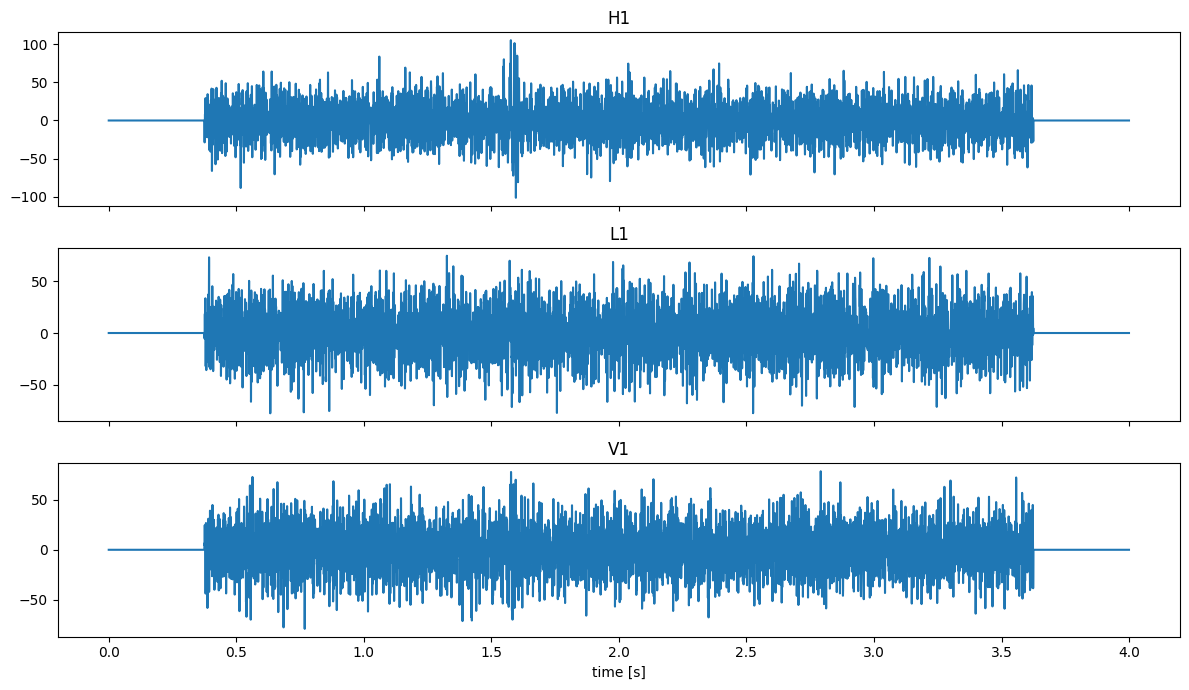

In [17]:
import matplotlib.pyplot as plt

sample_idx = 0
time = np.arange(X.shape[-1]) / 4096.0

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for c, det in enumerate(detector_names):
    axes[c].plot(time, X[sample_idx, c])
    axes[c].set_title(det)

plt.xlabel("time [s]")
plt.tight_layout()
plt.show()

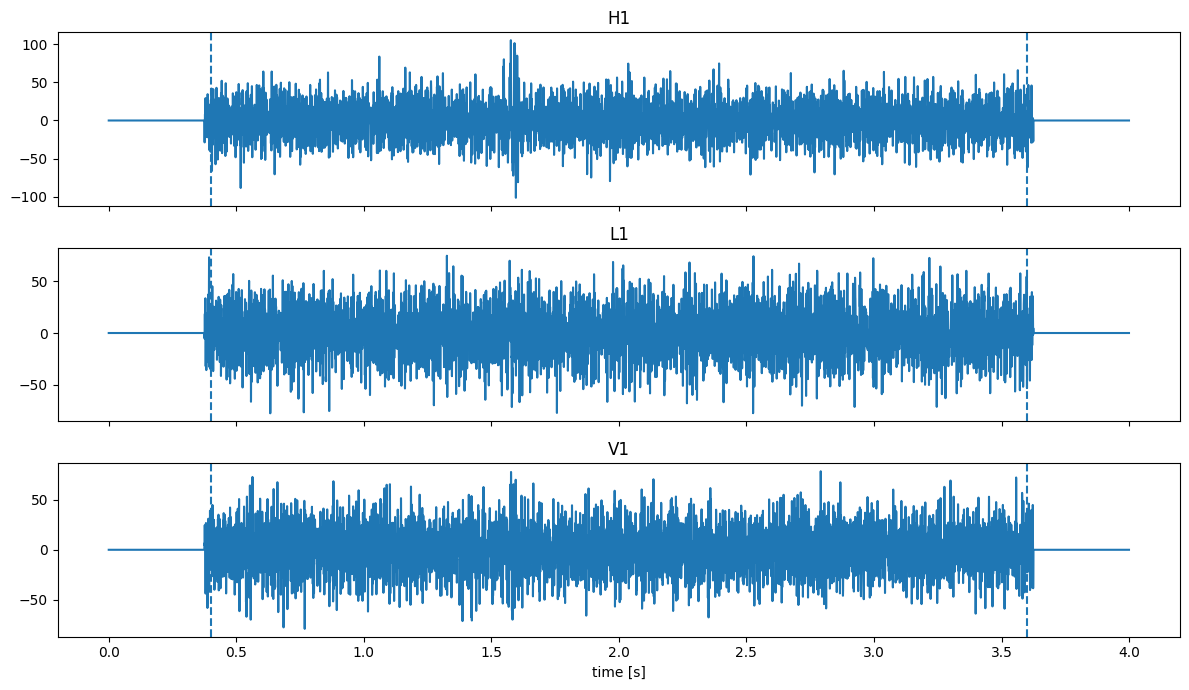

In [18]:
sample_idx = 0
m = metadata[sample_idx]
placement = m["placement"]

safe_start = placement["safe_margin_start"]
safe_end = placement["safe_margin_end"]

time = np.arange(X.shape[-1]) / 4096.0

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for c, det in enumerate(detector_names):
    axes[c].plot(time, X[sample_idx, c])
    axes[c].axvline(safe_start, linestyle="--")
    axes[c].axvline(4.0 - safe_end, linestyle="--")
    axes[c].set_title(det)

plt.xlabel("time [s]")
plt.tight_layout()
plt.show()

In [19]:
slack_before = margin_before - safe_start
slack_after = margin_after - safe_end

print("slack_before min/median/max:", slack_before.min(), np.median(slack_before), slack_before.max())
print("slack_after  min/median/max:", slack_after.min(), np.median(slack_after), slack_after.max())

slack_before min/median/max: 0.03234324455261228 1.5177953004837037 2.9486430644989015
slack_after  min/median/max: 0.0001362323760986106 1.1874401330947877 2.813408708572388


In [20]:
eps = 2 / 4096  # dos samples
near_start = np.mean(slack_before < eps)
near_end = np.mean(slack_after < eps)

print("fraction near start margin:", near_start)
print("fraction near end margin:", near_end)

fraction near start margin: 0.0
fraction near end margin: 0.01
